<a href="https://colab.research.google.com/github/s3d-0x/PassGen/blob/main/AI-Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Classification - Fetal Health

df_fetal = df_fetal = pd.read_csv("/content/drive/MyDrive/CS362/fetal_health.csv")
df_fetal = df_fetal.drop_duplicates()

X_fetal = df_fetal.drop("fetal_health", axis=1)
y_fetal = df_fetal["fetal_health"]

scaler_fetal = StandardScaler()
X_fetal_scaled = scaler_fetal.fit_transform(X_fetal)

X_train_fetal, X_test_fetal, y_train_fetal, y_test_fetal = train_test_split(
    X_fetal_scaled,
    y_fetal,
    test_size=0.2,
    random_state=42,
    stratify=y_fetal
)

print("Classification preprocessing done.")
#
# data after processing
print("Shape of X_train:", X_train_fetal.shape)
print("Shape of X_test:", X_test_fetal.shape)
print("Shape of y_train:", y_train_fetal.shape)
print("Shape of y_test:", y_test_fetal.shape)

# data after scaling
print("First 5 rows of X_train_scaled:\n", X_train_fetal[:5])
print("Distribution of classes in y_train:\n", y_train_fetal.value_counts())


Classification preprocessing done.
Shape of X_train: (1690, 21)
Shape of X_test: (423, 21)
Shape of y_train: (1690,)
Shape of y_test: (423,)
First 5 rows of X_train_scaled:
 [[-0.13266535 -0.56540599 -0.20339237  0.20846351  1.04520715 -0.05765272
  -0.26963969 -0.98952649  0.52589976 -0.26155828  2.08349476  0.72989373
  -1.4063345  -0.73016611  0.99047519 -0.46014951  0.09425882 -0.29472043
  -0.07526123  0.4165336   1.1155051 ]
 [-0.539371    1.24318398  0.01031627 -0.47181972  1.04520715 -0.05765272
  -0.26963969 -0.98952649  0.63900166 -0.53429448 -0.77538383  1.80685892
  -1.23715995  1.88954222  2.68483567 -0.46014951 -0.02770621 -0.48694523
  -0.14434333  1.03654139 -0.5213437 ]
 [-0.33601817 -0.82377599 -0.01105459  1.22888835 -0.64120298 -0.05765272
  -0.26963969  1.5142996   0.86520547  0.12027241 -1.20155207 -1.11633232
   1.02977901 -0.73016611 -0.7038853  -0.46014951 -0.57654881 -0.48694523
  -0.55883591 -0.61681271 -2.15819251]
 [ 0.98577521 -0.82377599 -0.20339237 -0.81

In [ ]:
# Regression - Body Fat

df_bodyfat = df_bodyfat = pd.read_csv("/content/drive/MyDrive/CS362/bodyfat.csv")
df_bodyfat = df_bodyfat.drop_duplicates()

X_bodyfat = df_bodyfat.drop("BodyFat", axis=1)
y_bodyfat = df_bodyfat["BodyFat"]

scaler_bodyfat = StandardScaler()
X_bodyfat_scaled = scaler_bodyfat.fit_transform(X_bodyfat)

X_train_bodyfat, X_test_bodyfat, y_train_bodyfat, y_test_bodyfat = train_test_split(
    X_bodyfat_scaled,
    y_bodyfat,
    test_size=0.2,
    random_state=42
)

print("Regression preprocessing done.")
#
# data after processing
print("Shape of X_train:", X_train_bodyfat.shape)
print("Shape of X_test:", X_test_bodyfat.shape)
print("Shape of y_train:", y_train_bodyfat.shape)
print("Shape of y_test:", y_test_bodyfat.shape)

# first 5 rows of X_train after scaling
print("First 5 rows of X_train_scaled:\n", X_train_bodyfat[:5])

# some values ​​of y_train
print("First 5 values of y_train:\n", y_train_bodyfat[:5])


Regression preprocessing done.
Shape of X_train: (201, 14)
Shape of X_test: (51, 14)
Shape of y_train: (201,)
Shape of y_test: (51,)
First 5 rows of X_train_scaled:
 [[-0.34084098 -0.46791091 -0.41507251  0.16445826 -0.40891536 -0.94181828
  -0.59990299 -0.60207899 -0.11565025 -1.03467436 -0.4152348   0.14147551
  -0.18043977 -1.2125412 ]
 [-0.43560957  0.72474132  0.65036077  0.50640117  0.78642601  0.80532561
   0.69171924 -0.04262506 -0.42102144 -0.24531476 -0.6517075   1.20273921
   0.76170376  0.71934741]
 [-1.82554882 -0.07036017  1.5027074  -0.10909607  1.19861269  2.46927216
   1.98334147  1.00635106  0.78137761  0.7102258  -0.76994386  0.83792981
   1.00963626 -0.89055976]
 [ 0.64369932  0.48621087 -1.01171515 -0.10909607 -1.31572605 -0.95370361
  -1.06451531 -0.50417455 -1.06993521 -0.86849339 -0.94729838 -0.32282736
  -1.1721698  -0.46125118]
 [-1.2306127  -1.581053    0.94015862 -0.10909607  1.19861269  1.19754158
   0.73818047  0.88047392  1.71657687  0.91795201  0.8853650

In [ ]:
# Classification Models Results Storage
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

classification_results = []

# -------------------------------------------------------
# 1. Logistic Regression
# -------------------------------------------------------
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_fetal, y_train_fetal)

# Predictions
y_pred_log = log_reg.predict(X_test_fetal)
y_train_pred_log = log_reg.predict(X_train_fetal) # Calculate train acc to check for overfitting

# Metrics
log_test_acc = accuracy_score(y_test_fetal, y_pred_log)
log_train_acc = accuracy_score(y_train_fetal, y_train_pred_log)
log_f1 = f1_score(y_test_fetal, y_pred_log, average='weighted')

# Calculate ROC-AUC
try:
    y_prob_log = log_reg.predict_proba(X_test_fetal)
    # Use 'ovr' for multiclass ROC
    log_roc = roc_auc_score(y_test_fetal, y_prob_log, multi_class='ovr')
except:
    log_roc = "N/A"

print(f"Logistic Regression -> Train Acc: {log_train_acc:.4f}, Test Acc: {log_test_acc:.4f}")

classification_results.append(["Logistic Regression", log_test_acc, log_train_acc, log_f1, log_roc])

# -------------------------------------------------------
# 2. Random Forest Classifier
# -------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_fetal, y_train_fetal)

# Predictions
y_pred_rf = rf_clf.predict(X_test_fetal)
y_train_pred_rf = rf_clf.predict(X_train_fetal)

# Metrics
rf_test_acc = accuracy_score(y_test_fetal, y_pred_rf)
rf_train_acc = accuracy_score(y_train_fetal, y_train_pred_rf)
rf_f1 = f1_score(y_test_fetal, y_pred_rf, average='weighted')

try:
    y_prob_rf = rf_clf.predict_proba(X_test_fetal)
    rf_roc = roc_auc_score(y_test_fetal, y_prob_rf, multi_class='ovr')
except:
    rf_roc = "N/A"

print(f"Random Forest -> Train Acc: {rf_train_acc:.4f}, Test Acc: {rf_test_acc:.4f}")

classification_results.append(["Random Forest", rf_test_acc, rf_train_acc, rf_f1, rf_roc])

# -------------------------------------------------------
# 3. Support Vector Machine (SVM)
# -------------------------------------------------------
from sklearn.svm import SVC

print("Training SVM...")
# probability=True is required for ROC-AUC
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_fetal, y_train_fetal)

# Predictions
y_pred_svm = svm_model.predict(X_test_fetal)
y_train_pred_svm = svm_model.predict(X_train_fetal)

# Metrics
svm_test_acc = accuracy_score(y_test_fetal, y_pred_svm)
svm_train_acc = accuracy_score(y_train_fetal, y_train_pred_svm)
svm_f1 = f1_score(y_test_fetal, y_pred_svm, average='weighted')

try:
    y_prob_svm = svm_model.predict_proba(X_test_fetal)
    svm_roc = roc_auc_score(y_test_fetal, y_prob_svm, multi_class='ovr')
except:
    svm_roc = "N/A"

print(f"SVM -> Train Acc: {svm_train_acc:.4f}, Test Acc: {svm_test_acc:.4f}")

classification_results.append(["SVM", svm_test_acc, svm_train_acc, svm_f1, svm_roc])

# -------------------------------------------------------
# 4. XGBoost Classifier
# -------------------------------------------------------
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

print("Training XGBoost...")
# XGBoost requires encoded labels (0, 1, 2...)
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train_fetal)
y_test_xgb = le.transform(y_test_fetal)

xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train_fetal, y_train_xgb)

# Predictions
y_pred_xgb = xgb_clf.predict(X_test_fetal)
y_train_pred_xgb = xgb_clf.predict(X_train_fetal)

# Metrics
xgb_test_acc = accuracy_score(y_test_xgb, y_pred_xgb)
xgb_train_acc = accuracy_score(y_train_xgb, y_train_pred_xgb)
xgb_f1 = f1_score(y_test_xgb, y_pred_xgb, average='weighted')

try:
    y_prob_xgb = xgb_clf.predict_proba(X_test_fetal)
    xgb_roc = roc_auc_score(y_test_xgb, y_prob_xgb, multi_class='ovr')
except:
    xgb_roc = "N/A"

print(f"XGBoost -> Train Acc: {xgb_train_acc:.4f}, Test Acc: {xgb_test_acc:.4f}")

classification_results.append(["XGBoost", xgb_test_acc, xgb_train_acc, xgb_f1, xgb_roc])

# -------------------------------------------------------
# Final Comparison Table
# -------------------------------------------------------
classification_df = pd.DataFrame(
    classification_results,
    columns=["Model", "Test Accuracy", "Train Accuracy", "F1-Score", "ROC-AUC"]
)

print("\n=== Final Classification Report ===")
print(classification_df)

Training Logistic Regression...
Logistic Regression -> Train Acc: 0.9024, Test Acc: 0.8889
Training Random Forest...
Random Forest -> Train Acc: 0.9988, Test Acc: 0.9456
Training SVM...
SVM -> Train Acc: 0.9314, Test Acc: 0.9031
Training XGBoost...
XGBoost -> Train Acc: 0.9988, Test Acc: 0.9622

=== Final Classification Report ===
                 Model  Test Accuracy  Train Accuracy  F1-Score   ROC-AUC
0  Logistic Regression       0.888889        0.902367  0.884927  0.968054
1        Random Forest       0.945626        0.998817  0.942899  0.986288
2                  SVM       0.903073        0.931361  0.895398  0.974510
3              XGBoost       0.962175        0.998817  0.960949  0.990611


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# initialize model
lin_reg = LinearRegression()

# train
lin_reg.fit(X_train_bodyfat, y_train_bodyfat)

# predict
y_pred_lin = lin_reg.predict(X_test_bodyfat)

# metrics
lin_mae = mean_absolute_error(y_test_bodyfat, y_pred_lin)
lin_mse = mean_squared_error(y_test_bodyfat, y_pred_lin)
lin_rmse = np.sqrt(lin_mse)
lin_r2 = r2_score(y_test_bodyfat, y_pred_lin)

print("Linear Regression Results:")
print("MAE:", lin_mae)
print("MSE:", lin_mse)
print("RMSE:", lin_rmse)
print("R2:", lin_r2)


Linear Regression Results:
MAE: 0.4595308051303704
MSE: 0.3803122094772222
RMSE: 0.6166945836289
R2: 0.9918244198502377


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_bodyfat, y_train_bodyfat)

y_pred_rf = rf_reg.predict(X_test_bodyfat)

rf_mae = mean_absolute_error(y_test_bodyfat, y_pred_rf)
rf_mse = mean_squared_error(y_test_bodyfat, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test_bodyfat, y_pred_rf)

print("Random Forest Regressor Results:")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)


Random Forest Regressor Results:
MAE: 0.15629411764705858
MSE: 0.04717056862745076
RMSE: 0.21718786482547953
R2: 0.998985973221702


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_bodyfat, y_train_bodyfat)

y_pred_gb = gb_reg.predict(X_test_bodyfat)

gb_mae = mean_absolute_error(y_test_bodyfat, y_pred_gb)
gb_mse = mean_squared_error(y_test_bodyfat, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test_bodyfat, y_pred_gb)

print("Gradient Boosting Regressor Results:")
print("MAE:", gb_mae)
print("MSE:", gb_mse)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)


Gradient Boosting Regressor Results:
MAE: 0.20218631519015617
MSE: 0.07818314765384043
RMSE: 0.27961249552521866
R2: 0.9983192951105007


In [ ]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

xgb_reg.fit(X_train_bodyfat, y_train_bodyfat)

y_pred_xgb = xgb_reg.predict(X_test_bodyfat)

xgb_mae = mean_absolute_error(y_test_bodyfat, y_pred_xgb)
xgb_mse = mean_squared_error(y_test_bodyfat, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test_bodyfat, y_pred_xgb)

print("XGBoost Regressor Results:")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)


XGBoost Regressor Results:
MAE: 0.3422079591190117
MSE: 0.22851000214190337
RMSE: 0.4780271981194201
R2: 0.9950877153270954


In [ ]:
regression_results = [
    ["Linear Regression", lin_mae, lin_mse, lin_rmse, lin_r2],
    ["Random Forest", rf_mae, rf_mse, rf_rmse, rf_r2],
    ["Gradient Boosting", gb_mae, gb_mse, gb_rmse, gb_r2],
    ["XGBoost", xgb_mae, xgb_mse, xgb_rmse, xgb_r2]
]

regression_df = pd.DataFrame(
    regression_results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

regression_df


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.459531,0.380312,0.616695,0.991824
1,Random Forest,0.156294,0.047171,0.217188,0.998986
2,Gradient Boosting,0.202186,0.078183,0.279612,0.998319
3,XGBoost,0.342208,0.228510,0.478027,0.995088


Final Accuracy: 0.9527

Classification report:

              precision    recall  f1-score   support

         1.0       0.95      1.00      0.97       330
         2.0       0.93      0.72      0.82        58
         3.0       1.00      0.91      0.96        35

    accuracy                           0.95       423
   macro avg       0.96      0.88      0.91       423
weighted avg       0.95      0.95      0.95       423



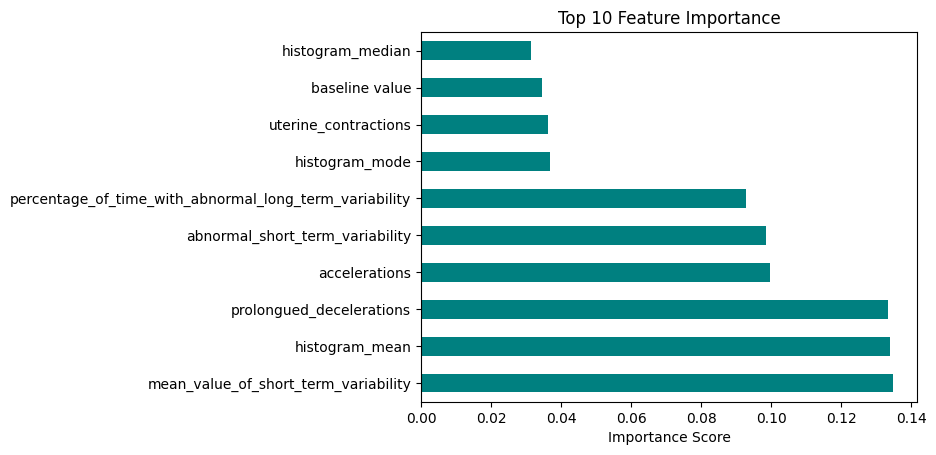

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train_fetal)
y_test_xgb = le.transform(y_test_fetal)

temp_xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1],
    'max_depth' : [3, 5]
}

grid_search = GridSearchCV(estimator=temp_xgb, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_fetal, y_train_xgb)

best_xgb = grid_search.best_estimator_

ensemble_model = VotingClassifier(
    estimators=[('xgb', best_xgb), ('rf', rf_clf), ('svm', svm_model)],
    voting='hard'
)

ensemble_model.fit(X_train_fetal, y_train_fetal)

final_preds = ensemble_model.predict(X_test_fetal)
final_acc = accuracy_score(y_test_fetal, final_preds)

print("Final Accuracy: {:.4f}".format(final_acc))
print("\nClassification report:\n")
print(classification_report(y_test_fetal, final_preds))

importances = pd.Series(best_xgb.feature_importances_, index=X_fetal.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("bodyfat.csv")
df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [ ]:
target = "BodyFat"

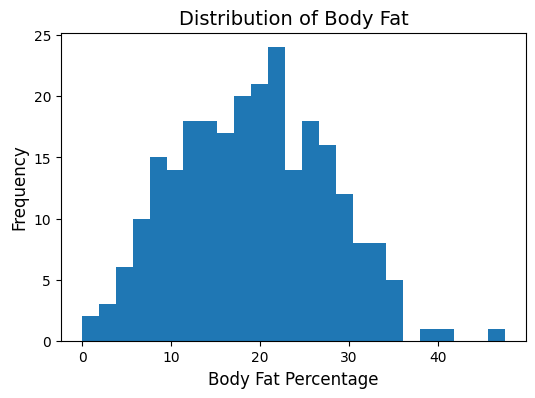

In [ ]:
#univariate analysis
plt.figure(figsize=(6, 4))
plt.hist(
    df[target],
    bins=25,
)
plt.title("Distribution of Body Fat", fontsize=14)
plt.xlabel("Body Fat Percentage", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()


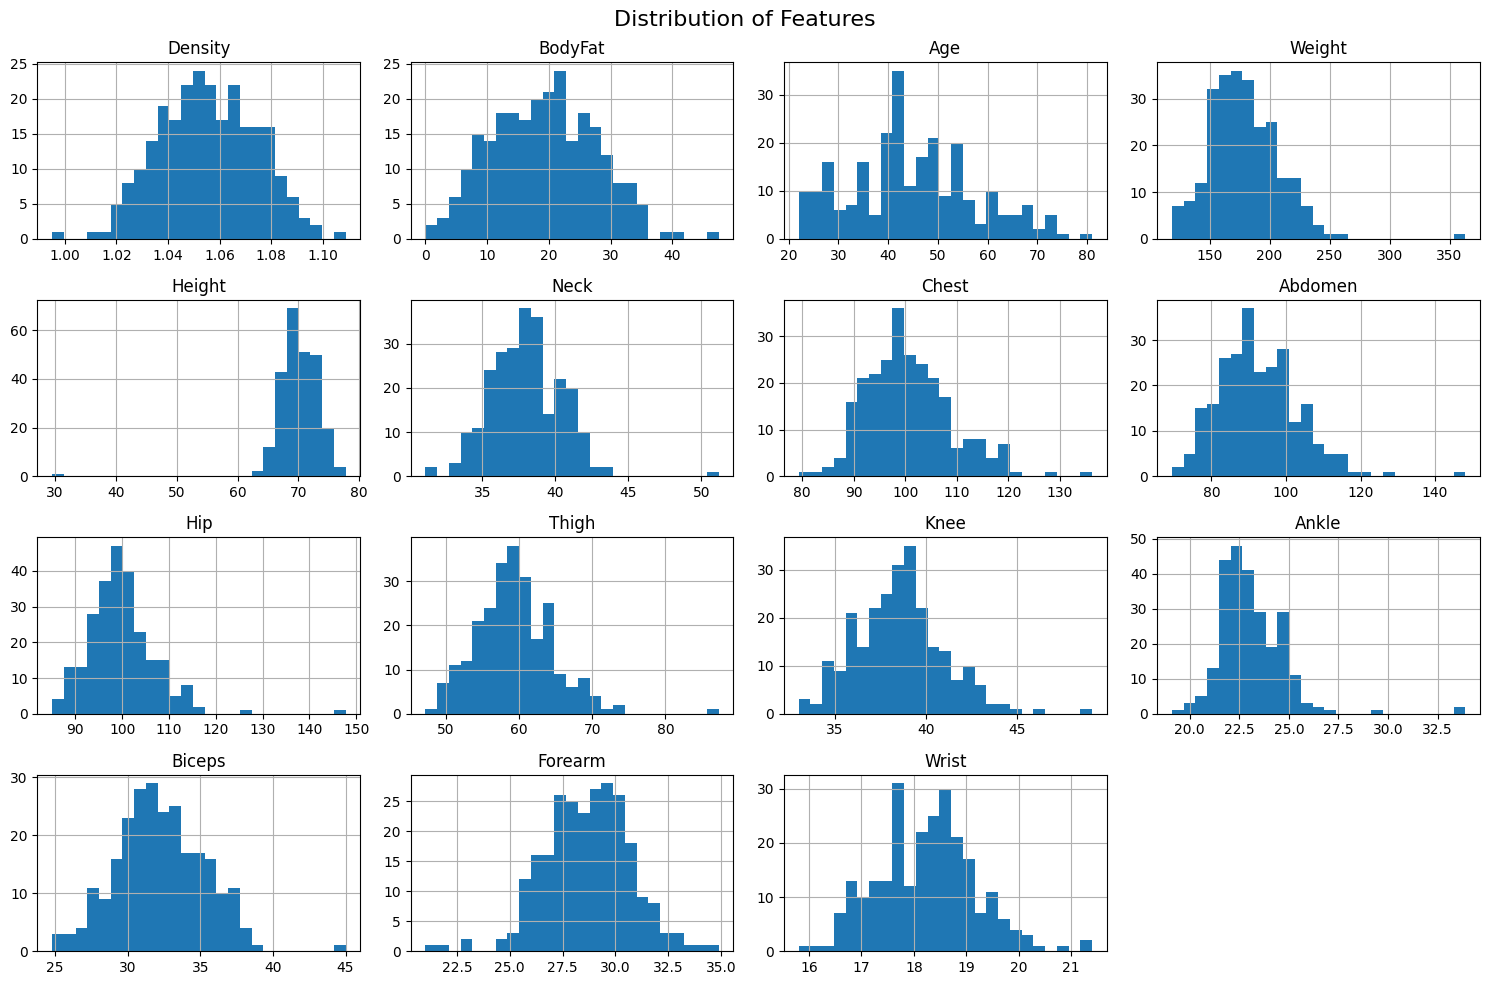

In [ ]:
#histogram
df.hist(
    figsize=(15, 10),
    bins=25
)
plt.suptitle("Distribution of Features", fontsize=16)
plt.tight_layout()
plt.show()

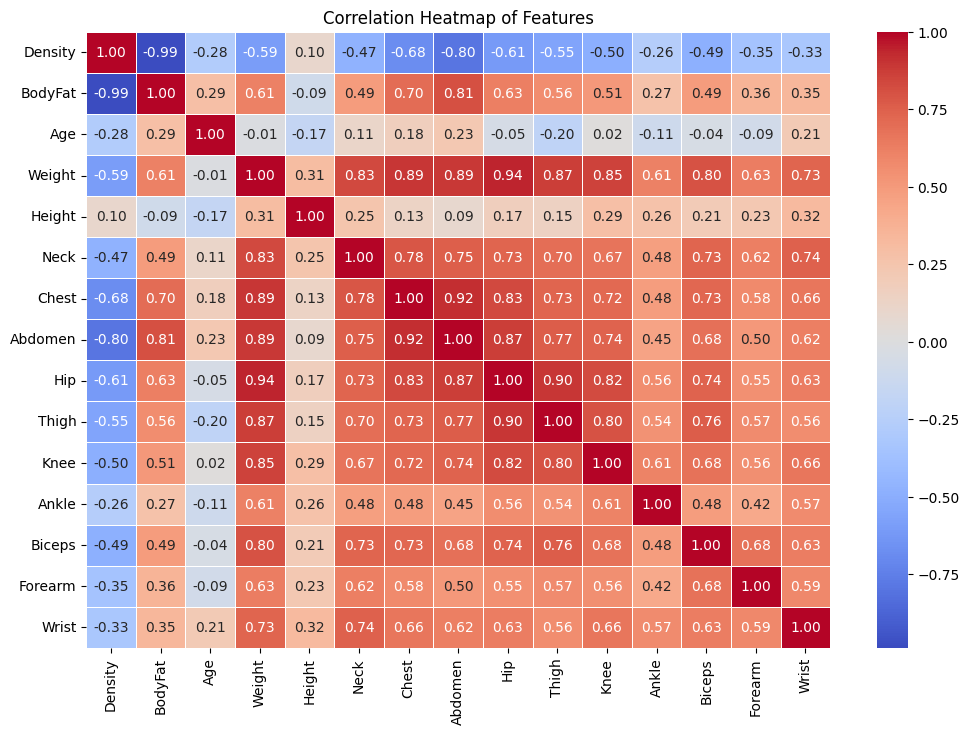

In [ ]:
#correlation heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
#feature engineering
df["Weight_Height_Ratio"] = df["Weight"] / df["Height"]
df["LowerBody_Avg"] = (df["Hip"] + df["Thigh"] + df["Knee"]) / 3

In [ ]:
X = df.drop(columns=[target])
y = df[target]

In [ ]:
#regression
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k=8)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected features using SelectKBest:")
print(selected_features)

Selected features using SelectKBest:
Index(['Density', 'Weight', 'Chest', 'Abdomen', 'Hip', 'Thigh',
       'Weight_Height_Ratio', 'LowerBody_Avg'],
      dtype='object')


In [ ]:
#recursive feture elimintion
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
model = LinearRegression()
rfe = RFE(model, n_features_to_select=8)
rfe.fit(X, y)
rfe_features = X.columns[rfe.support_]
print("Selected features using RFE:")
print(rfe_features)

Selected features using RFE:
Index(['Density', 'Chest', 'Abdomen', 'Thigh', 'Ankle', 'Biceps', 'Forearm',
       'Weight_Height_Ratio'],
      dtype='object')


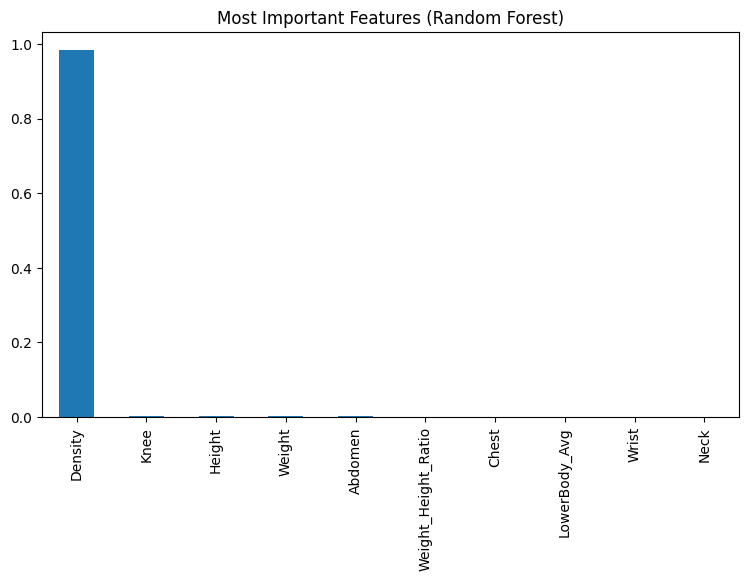

In [ ]:
#feature importance
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(9,5))
importance.head(10).plot(kind="bar")
plt.title("Most Important Features (Random Forest)")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
